# QA: Ground Truth Correction Magnitude by Component

Quantify the magnitude of ground truth phase error correction fields (vx, vy, vz)
across all patients to check whether one component has systematically smaller corrections.

All corrections are VENC-normalised (values in approx [-1, 1]).
We compute per-patient, per-component statistics on the downsampled (128×128×64) volumes.

In [1]:
import platform
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd

from vascular_superenhancement.utils.path_config import load_path_config, _PROJECT_ROOT

config_name = "local_mac" if platform.system() == "Darwin" else "all_patients"
pc = load_path_config(config_name)

WORKING_DIR = pc.working_dir
PATIENT_DATA_DIR = WORKING_DIR / "patient_data"
DOWNSAMPLED_FOLDER = "downsampled_full_fov_128x128x64"
COMPONENTS = ["vx", "vy", "vz"]

splits_df = pd.read_csv(_PROJECT_ROOT / "splits" / "splits_01-15-26.csv")
patients_df = splits_df[splits_df["split"].isin(["train", "validation", "test"])].copy()
patients_df = patients_df.sort_values(["split", "patient_id"]).reset_index(drop=True)

print(f"Patients: {len(patients_df)}")
print(patients_df["split"].value_counts())

Found project root at: /home/ayeluru/vascular-superenhancement-4d-flow
Patients: 215
split
train         165
test           28
validation     22
Name: count, dtype: int64


In [2]:
rows = []

for _, row in patients_df.iterrows():
    pid = row["patient_id"]
    split = row["split"]
    root = PATIENT_DATA_DIR / pid / "nifti" / DOWNSAMPLED_FOLDER

    gt_paths = {
        comp: root / f"ground_truth_correction_{comp}_{pid}.nii.gz"
        for comp in COMPONENTS
    }

    if not all(p.exists() for p in gt_paths.values()):
        print(f"  SKIP {pid}: missing ground truth files")
        continue

    for comp in COMPONENTS:
        vol = nib.load(str(gt_paths[comp])).get_fdata(dtype=np.float32)
        rows.append({
            "patient_id": pid,
            "split": split,
            "component": comp,
            "min": float(vol.min()),
            "max": float(vol.max()),
            "range": float(vol.max() - vol.min()),
            "mean": float(vol.mean()),
            "std": float(vol.std()),
            "abs_mean": float(np.abs(vol).mean()),
            "abs_p50": float(np.percentile(np.abs(vol), 50)),
            "abs_p95": float(np.percentile(np.abs(vol), 95)),
            "abs_p99": float(np.percentile(np.abs(vol), 99)),
            "abs_max": float(np.abs(vol).max()),
        })

stats_df = pd.DataFrame(rows)
print(f"Loaded stats for {stats_df['patient_id'].nunique()} patients, "
      f"{len(stats_df)} rows")
stats_df.head(9)

  SKIP Coosimo: missing ground truth files
Loaded stats for 214 patients, 642 rows


,patient_id,split,component,min,max,range,mean,std,abs_mean,abs_p50,abs_p95,abs_p99,abs_max
0,Balboloop,test,vx,-0.069462,0.054323,0.123784,-0.006139,0.016676,0.013859,0.011552,0.036763,0.049204,0.069462
1,Balboloop,test,vy,-0.034504,0.067157,0.101661,0.002137,0.011101,0.008544,0.006590,0.021687,0.034302,0.067157
2,Balboloop,test,vz,-0.078458,0.057271,0.135729,0.001150,0.015445,0.011901,0.009396,0.028733,0.044430,0.078458
3,Biswifo,test,vx,-0.110832,0.081061,0.191893,-0.020767,0.027839,0.026485,0.020919,0.073166,0.094011,0.110832
4,Biswifo,test,vy,-0.104011,0.127259,0.231270,0.009478,0.025912,0.021362,0.016273,0.057581,0.067742,0.127259
5,Biswifo,test,vz,-0.063056,0.104378,0.167435,0.017296,0.022262,0.021083,0.015648,0.061674,0.076042,0.104378
6,Bomatog,test,vx,-0.103534,0.077278,0.180812,-0.010318,0.021397,0.018082,0.013367,0.050983,0.065482,0.103534
7,Bomatog,test,vy,-0.081916,0.058667,0.140583,-0.002536,0.016330,0.012796,0.009939,0.033115,0.048092,0.081916
8,Bomatog,test,vz,-0.046663,0.088691,0.135354,0.009173,0.016824,0.014512,0.010799,0.041630,0.053913,0.088691


In [3]:
agg = stats_df.groupby("component").agg(
    mean_range=("range", "mean"),
    mean_std=("std", "mean"),
    mean_abs_mean=("abs_mean", "mean"),
    mean_abs_p50=("abs_p50", "mean"),
    mean_abs_p95=("abs_p95", "mean"),
    mean_abs_p99=("abs_p99", "mean"),
    mean_abs_max=("abs_max", "mean"),
    mean_min=("min", "mean"),
    mean_max=("max", "mean"),
).round(6)

print("=== Across-patient means, grouped by component ===")
agg

=== Across-patient means, grouped by component ===


,mean_range,mean_std,mean_abs_mean,mean_abs_p50,mean_abs_p95,mean_abs_p99,mean_abs_max,mean_min,mean_max
component,,,,,,,,,
vx,0.177585,0.021899,0.018702,0.015097,0.048596,0.064603,0.099406,-0.092163,0.085422
vy,0.154834,0.018496,0.015702,0.012911,0.039782,0.055004,0.092917,-0.082442,0.072392
vz,0.176287,0.020046,0.016758,0.012707,0.045905,0.060403,0.101487,-0.088546,0.087740


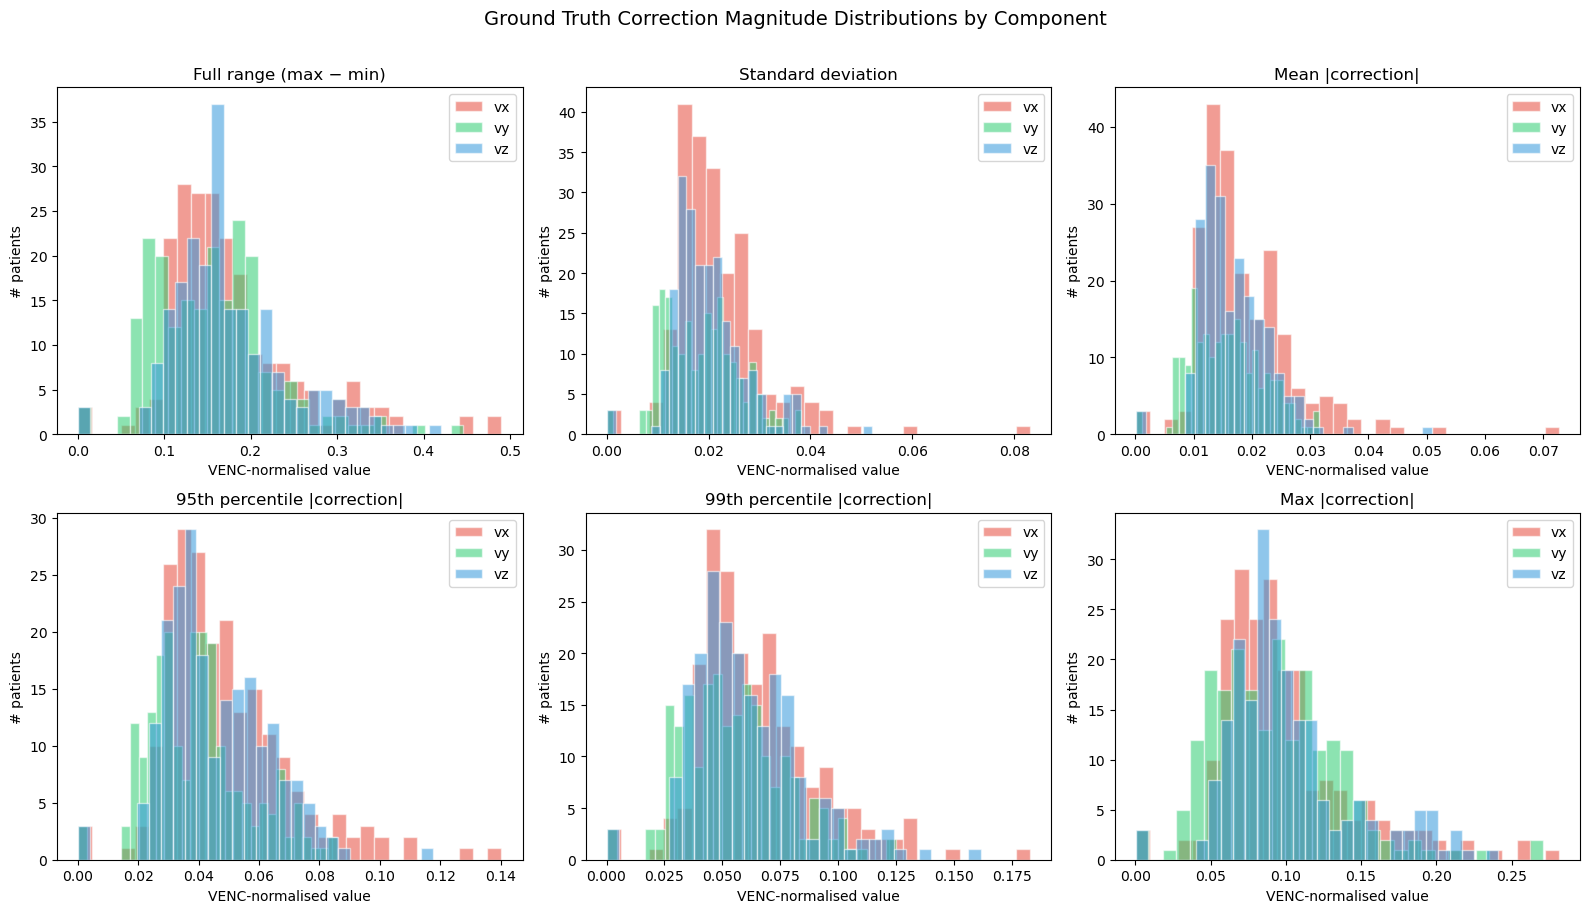

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

metrics = [
    ("range", "Full range (max − min)"),
    ("std", "Standard deviation"),
    ("abs_mean", "Mean |correction|"),
    ("abs_p95", "95th percentile |correction|"),
    ("abs_p99", "99th percentile |correction|"),
    ("abs_max", "Max |correction|"),
]

colors = {"vx": "#e74c3c", "vy": "#2ecc71", "vz": "#3498db"}

for ax, (metric, title) in zip(axes.flat, metrics):
    for comp in COMPONENTS:
        vals = stats_df.loc[stats_df["component"] == comp, metric]
        ax.hist(vals, bins=30, alpha=0.55, label=comp, color=colors[comp], edgecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("VENC-normalised value")
    ax.set_ylabel("# patients")
    ax.legend()

fig.suptitle("Ground Truth Correction Magnitude Distributions by Component", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

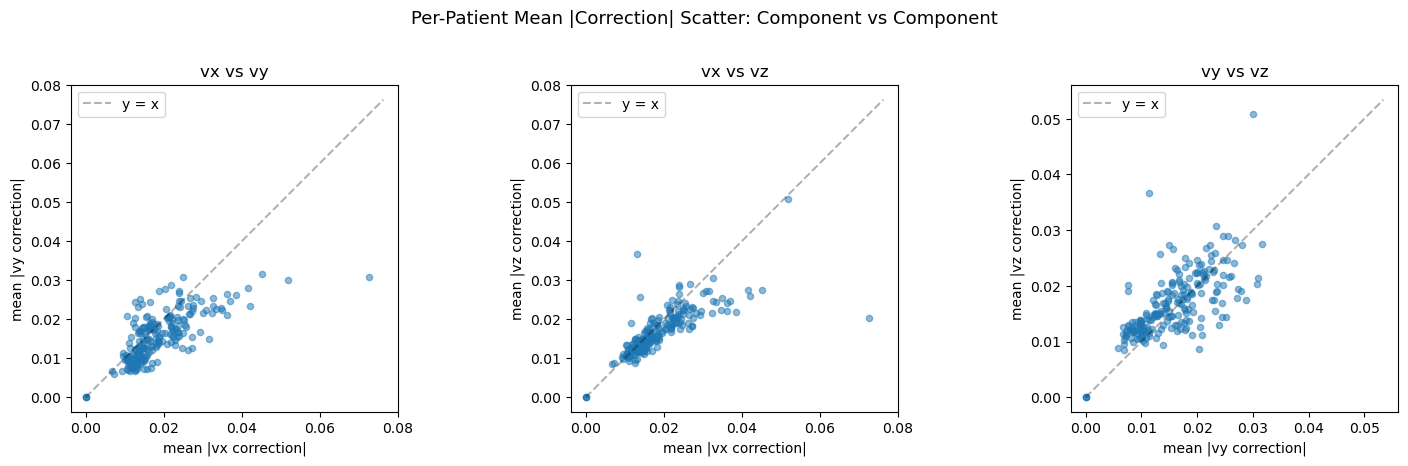

In [5]:
pivot_range = stats_df.pivot(index="patient_id", columns="component", values="abs_mean")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [("vx", "vy"), ("vx", "vz"), ("vy", "vz")]
for ax, (c1, c2) in zip(axes, pairs):
    ax.scatter(pivot_range[c1], pivot_range[c2], alpha=0.5, s=20)
    lim = max(pivot_range[c1].max(), pivot_range[c2].max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", alpha=0.3, label="y = x")
    ax.set_xlabel(f"mean |{c1} correction|")
    ax.set_ylabel(f"mean |{c2} correction|")
    ax.set_title(f"{c1} vs {c2}")
    ax.set_aspect("equal")
    ax.legend()

fig.suptitle("Per-Patient Mean |Correction| Scatter: Component vs Component", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

/tmp/ipykernel_2980072/397988733.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=COMPONENTS, patch_artist=True, widths=0.5)


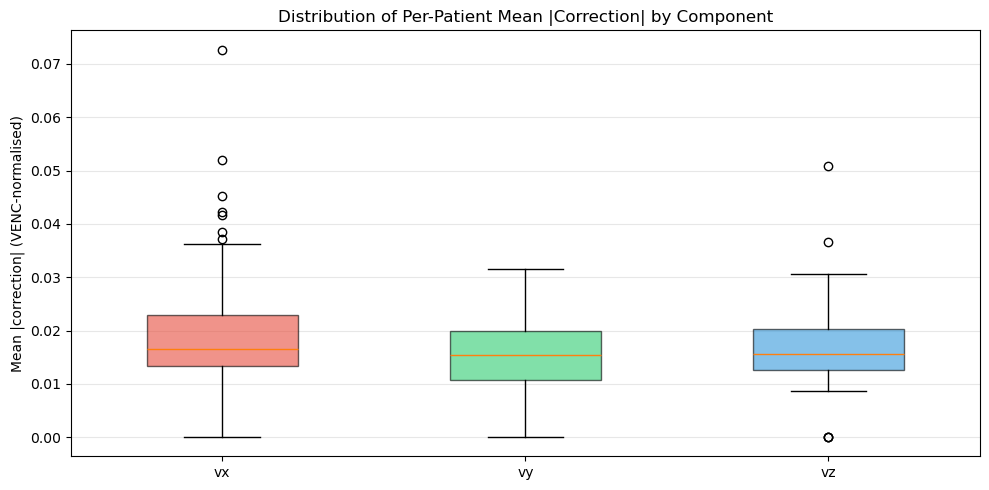

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

box_data = [stats_df.loc[stats_df["component"] == c, "abs_mean"] for c in COMPONENTS]
bp = ax.boxplot(box_data, labels=COMPONENTS, patch_artist=True, widths=0.5)
for patch, comp in zip(bp["boxes"], COMPONENTS):
    patch.set_facecolor(colors[comp])
    patch.set_alpha(0.6)

ax.set_ylabel("Mean |correction| (VENC-normalised)")
ax.set_title("Distribution of Per-Patient Mean |Correction| by Component")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
from scipy import stats as sp_stats

print("=== Paired t-tests on per-patient mean |correction| ===")
print("(Tests whether one component has systematically different magnitude)\n")

pivot = stats_df.pivot(index="patient_id", columns="component", values="abs_mean")

for c1, c2 in [("vx", "vy"), ("vx", "vz"), ("vy", "vz")]:
    t_stat, p_val = sp_stats.ttest_rel(pivot[c1], pivot[c2])
    diff = (pivot[c1] - pivot[c2]).mean()
    print(f"  {c1} vs {c2}:  mean diff = {diff:+.6f},  t = {t_stat:.3f},  p = {p_val:.2e}")

print("\n=== Paired t-tests on per-patient std ===")
pivot_std = stats_df.pivot(index="patient_id", columns="component", values="std")
for c1, c2 in [("vx", "vy"), ("vx", "vz"), ("vy", "vz")]:
    t_stat, p_val = sp_stats.ttest_rel(pivot_std[c1], pivot_std[c2])
    diff = (pivot_std[c1] - pivot_std[c2]).mean()
    print(f"  {c1} vs {c2}:  mean diff = {diff:+.6f},  t = {t_stat:.3f},  p = {p_val:.2e}")

=== Paired t-tests on per-patient mean |correction| ===
(Tests whether one component has systematically different magnitude)

  vx vs vy:  mean diff = +0.003000,  t = 7.451,  p = 2.29e-12
  vx vs vz:  mean diff = +0.001944,  t = 5.218,  p = 4.29e-07
  vy vs vz:  mean diff = -0.001056,  t = -3.185,  p = 1.67e-03

=== Paired t-tests on per-patient std ===
  vx vs vy:  mean diff = +0.003402,  t = 8.027,  p = 6.67e-14
  vx vs vz:  mean diff = +0.001853,  t = 5.048,  p = 9.57e-07
  vy vs vz:  mean diff = -0.001550,  t = -4.054,  p = 7.07e-05


In [8]:
print("=== Per-split summary (mean abs_mean across patients) ===")
split_comp = stats_df.groupby(["split", "component"])["abs_mean"].agg(["mean", "std", "count"]).round(6)
split_comp

=== Per-split summary (mean abs_mean across patients) ===


mean       std  count
split      component                           
test       vx         0.022805  0.007300     28
           vy         0.017671  0.004839     28
           vz         0.019207  0.004904     28
train      vx         0.018009  0.007866    164
           vy         0.015217  0.006327    164
           vz         0.016553  0.006238    164
validation vx         0.018641  0.012714     22
           vy         0.016808  0.006091     22
           vz         0.015167  0.003040     22